In [2]:
import numpy as np
ampl_loaded = np.load("ampl_pt_noise.npy")


thr=3.5 -> fake rate=142.16 Hz
thr=3.55 -> fake rate=116.64 Hz
thr=3.6 -> fake rate=95.84 Hz
thr=3.65 -> fake rate=80.54 Hz
thr=3.7 -> fake rate=68.24 Hz
thr=3.75 -> fake rate=58.57 Hz
thr=3.8 -> fake rate=50.15 Hz
thr=3.85 -> fake rate=42.76 Hz
thr=3.9 -> fake rate=36.67 Hz
thr=3.95 -> fake rate=32.12 Hz
thr=4 -> fake rate=28 Hz
thr=4.05 -> fake rate=24.03 Hz
thr=4.1 -> fake rate=20.42 Hz
thr=4.15 -> fake rate=16.54 Hz
thr=4.2 -> fake rate=12.58 Hz
thr=4.25 -> fake rate=9.23 Hz
thr=4.3 -> fake rate=6.61 Hz
thr=4.35 -> fake rate=4.26 Hz
thr=4.4 -> fake rate=2.73 Hz
thr=4.45 -> fake rate=1.73 Hz
thr=4.5 -> fake rate=1.03 Hz
thr=4.55 -> fake rate=0.55 Hz
thr=4.6 -> fake rate=0.39 Hz
thr=4.65 -> fake rate=0.25 Hz
thr=4.7 -> fake rate=0.13 Hz
thr=4.75 -> fake rate=0.05 Hz
thr=4.8 -> fake rate=0.01 Hz
thr=4.85 -> fake rate=0 Hz
thr=4.9 -> fake rate=0 Hz
thr=4.95 -> fake rate=0 Hz
thr=5 -> fake rate=0 Hz


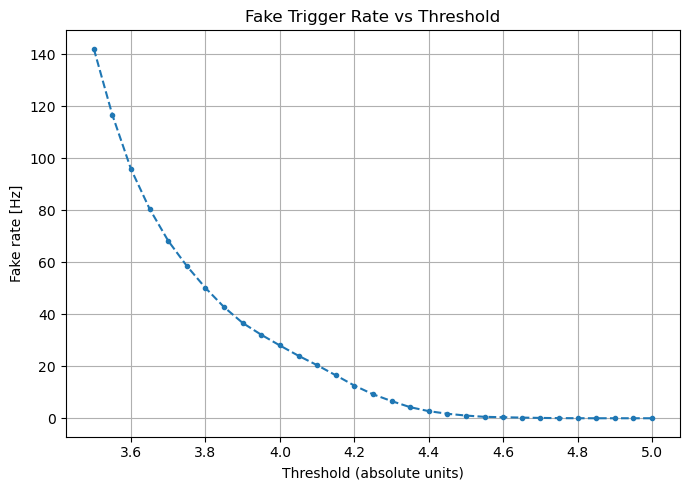

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ampl_loaded: 1D numpy array of your 100 s noise trace

T_seconds = 100.0  # trace duration in seconds

# Thresholds in the same units as ampl_loaded
thr_vals = np.arange(3.5, 5.0 + 1e-9, 0.05)  # 0.00, 0.05, ..., 5.00

# Count points that exceed the threshold (one-sided)
counts = (ampl_loaded[None, :] > thr_vals[:, None]).sum(axis=1).astype(int)

# Convert to fake rate [Hz]
fake_rate_hz = counts / T_seconds

# Print fake rates
for thr, r in zip(thr_vals, fake_rate_hz):
    print(f"thr={thr:g} -> fake rate={r:.6g} Hz")

# --- Dashed line plot of fake rate vs threshold ---
plt.figure(figsize=(7, 5))
plt.plot(thr_vals, fake_rate_hz, linestyle="--", marker="o", linewidth=1.5, markersize=3)
plt.xlabel("Threshold (absolute units)")
plt.ylabel("Fake rate [Hz]")
plt.title("Fake Trigger Rate vs Threshold")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()


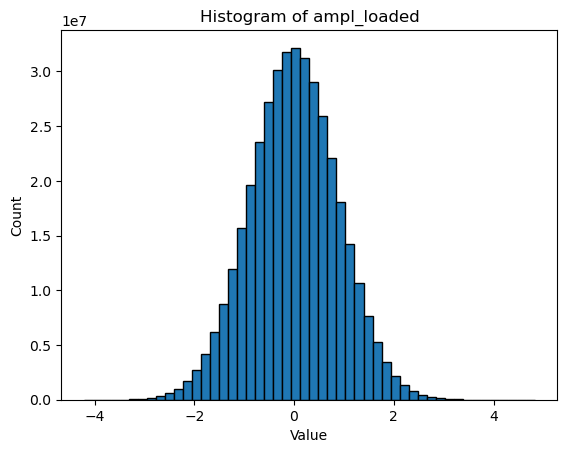

In [2]:
import matplotlib.pyplot as plt

# Plot histogram
plt.hist(ampl_loaded, bins=50, edgecolor="black")  # adjust bins as needed
plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Histogram of ampl_loaded")
plt.show()


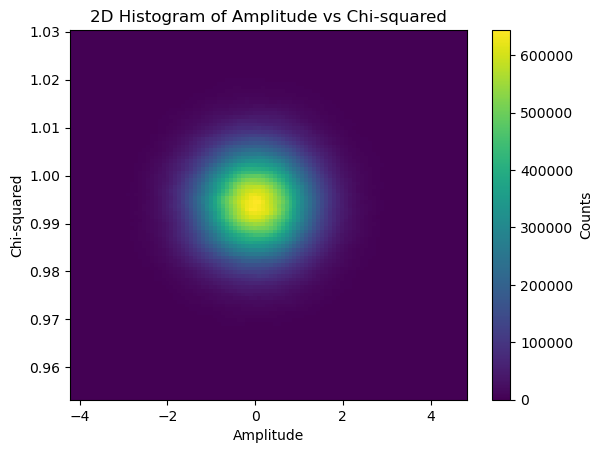

In [6]:
plt.hist2d(ampl_loaded, chisq_loaded, bins=100, cmap="viridis")
plt.colorbar(label="Counts")  # adds a colorbar for counts
plt.xlabel("Amplitude")
plt.ylabel("Chi-squared")
plt.title("2D Histogram of Amplitude vs Chi-squared")
plt.show()

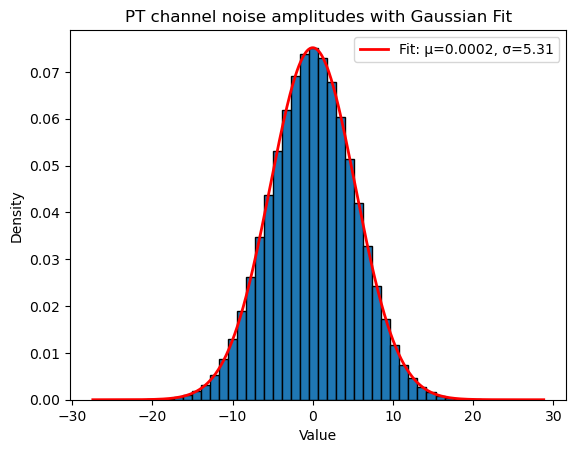

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Plot histogram
counts, bins, patches = plt.hist(ampl_loaded, bins=50, edgecolor="black", density=True)  
# use density=True so area under histogram = 1 (needed for Gaussian fit)

# Bin centers for plotting
bin_centers = 0.5 * (bins[1:] + bins[:-1])

# Fit a Gaussian
mu, sigma = norm.fit(ampl_loaded)  # mean and standard deviation

# Gaussian curve
x = np.linspace(min(ampl_loaded), max(ampl_loaded), 1000)
pdf = norm.pdf(x, mu, sigma)

# Plot Gaussian fit
plt.plot(x, pdf, "r-", linewidth=2, label=f"Fit: μ={mu:.4f}, σ={sigma:.2f}")
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("PT channel noise amplitudes with Gaussian Fit")
plt.legend()
plt.show()


In [9]:
import numpy as np
from scipy.stats import norm

mu = np.mean(ampl_loaded)   # or use the mu from norm.fit
sigma = 0.8742253662429997  # your given sigma

# Calculate thresholds
thr_3sigma = mu + 3 * sigma
thr_4sigma = mu + 4 * sigma
thr_5sigma = mu + 5 * sigma

# Count events beyond thresholds (both tails)
n_3sigma = np.sum(np.abs(ampl_loaded - mu) > 3 * sigma)
n_4sigma = np.sum(np.abs(ampl_loaded - mu) > 4 * sigma)
n_5sigma = np.sum(np.abs(ampl_loaded - mu) > 5 * sigma)

print(f"Events beyond 3σ: {n_3sigma}")
print(f"Events beyond 4σ: {n_4sigma}")
print(f"Events beyond 5σ: {n_5sigma}")


Events beyond 3σ: 1028940
Events beyond 4σ: 25698
Events beyond 5σ: 359


Number of events beyond 5σ: 359


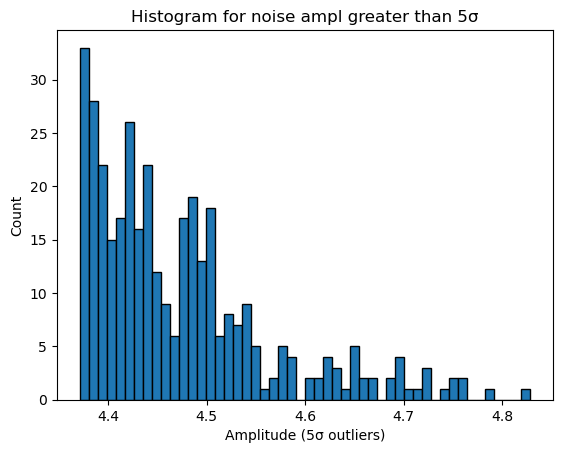

In [4]:
import numpy as np
import matplotlib.pyplot as plt

mu = np.mean(ampl_loaded)   
sigma = 0.8742253662429997  

# Select events beyond ±5σ
above_5sigma = ampl_loaded[np.abs(ampl_loaded - mu) > 5 * sigma]

print(f"Number of events beyond 5σ: {above_5sigma.size}")

# Plot histogram for those events
plt.hist(above_5sigma, bins=50, edgecolor="black")
plt.xlabel("Amplitude (5σ outliers)")
plt.ylabel("Count")
plt.title("Histogram for noise ampl greater than 5σ")
plt.show()


In [22]:
ampl_16 = np.load("/home/dwong/DELight_mtr/max_amp/max_amplitude_phonon_total_energy_16.npy")
ampl_0 = np.load("/home/dwong/DELight_mtr/max_amp/max_amplitude_phonon_total_energy_0.npy")

In [23]:
print(np.mean(ampl_0))
print(np.mean(ampl_16))

10.468297166490046
11.923784458924576


In [19]:
ampl_0

array([12.21061101,  9.7216809 , 12.74915258, 12.79260093, 15.44049746,
       12.27880038,  9.80879167, 10.1799942 , 12.61918431, 16.17411612,
       13.88114195, 10.47318249, 13.88922968,  7.05995455, 11.90995078,
        9.0902175 , 12.43333345, 11.02652028,  8.31303752, 16.15849774,
        9.41577654, 10.44726789, 11.47642166, 19.28187883,  9.45311677,
       12.59381607,  9.64540322, 13.16497793, 10.98403507,  8.71164424,
       11.0077602 ,  9.3314347 , 12.62496869, 11.49429988,  7.28546196,
        9.71874977, 13.59533752, 13.94972386, 14.22772908, 11.7777968 ,
        9.91773504, 19.43080234, 11.92723341, 15.05544585,  8.31990954,
       12.27943741, 12.5167614 ,  7.66428662, 15.5144131 , 14.50360048,
       13.58933863,  9.88973988,  9.46390554, 13.03354044, 10.02620788,
       11.09068355, 12.96632977,  8.83929292, 12.27988269, 10.44833885,
        9.67913752, 14.52773961, 11.37067998, 10.70146772, 12.07969056,
       10.64175758, 10.36476288, 14.5827794 , 11.55131225, 12.48